In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Loading Data


In [26]:
data= pd.read_csv("data.csv")
data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [27]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [28]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Repalcig categorial target value into binary

In [29]:
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True , errors='ignore')
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [30]:
data = data.sample(frac=1, random_state=42)

In [31]:
data = data.sample(frac=1, random_state=42)

In [32]:

data = data.sample(frac=1, random_state=42)

In [33]:
y = data['diagnosis'].values
x_data = data.drop(['diagnosis'], axis=1)

In [34]:
y

array([0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,

# Box Plot

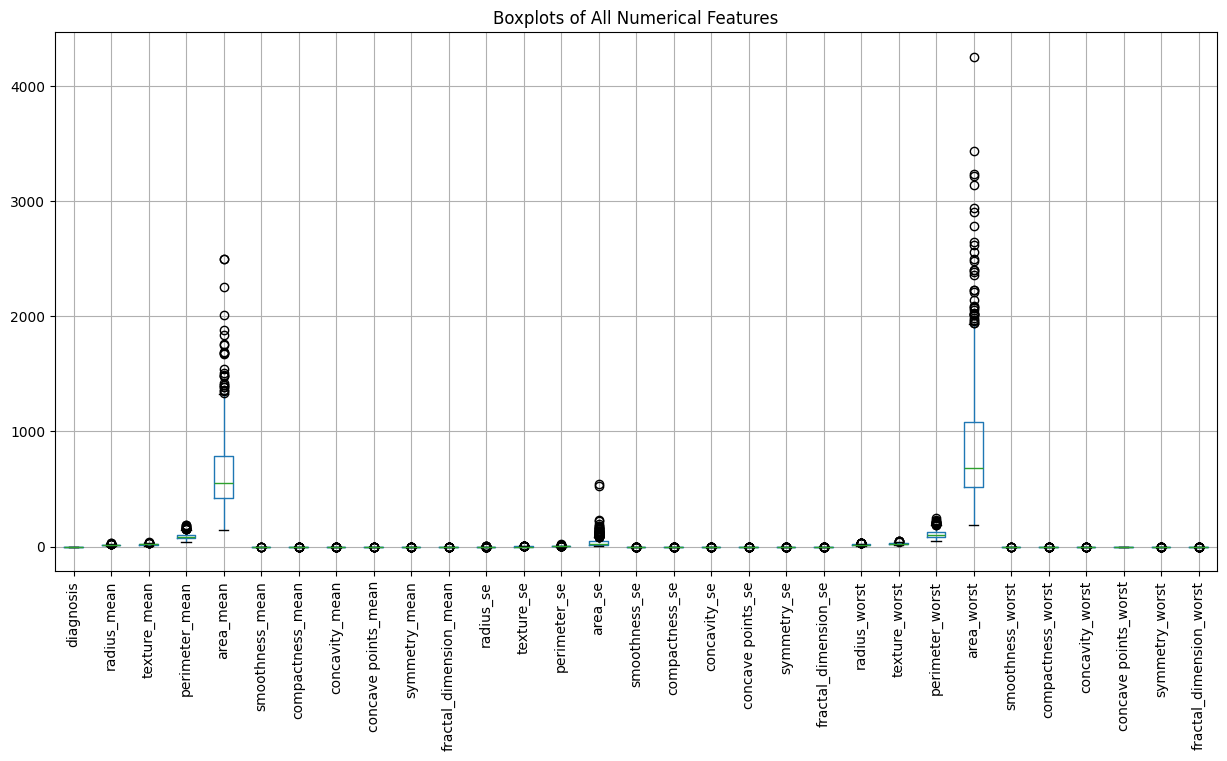

In [35]:
plt.figure(figsize=(15, 7))
data.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()


# Removing Outliers by Applying Standardisation

In [36]:
outlier_cols = [ 'area_mean','smoothness_mean',  'area_se', 'area_worst', ]

for col in outlier_cols:
    col_mean = data[col].mean()
    col_std = data[col].std()

    final_z_score = []


    for value in data[col]:
        z_score = (value - col_mean) / col_std
        final_z_score.append(float("{:.20f}".format(z_score)))

    data[col] = final_z_score

print(" Standardization Completed ")

 Standardization Completed 


# Box Plot after Standardisatoin

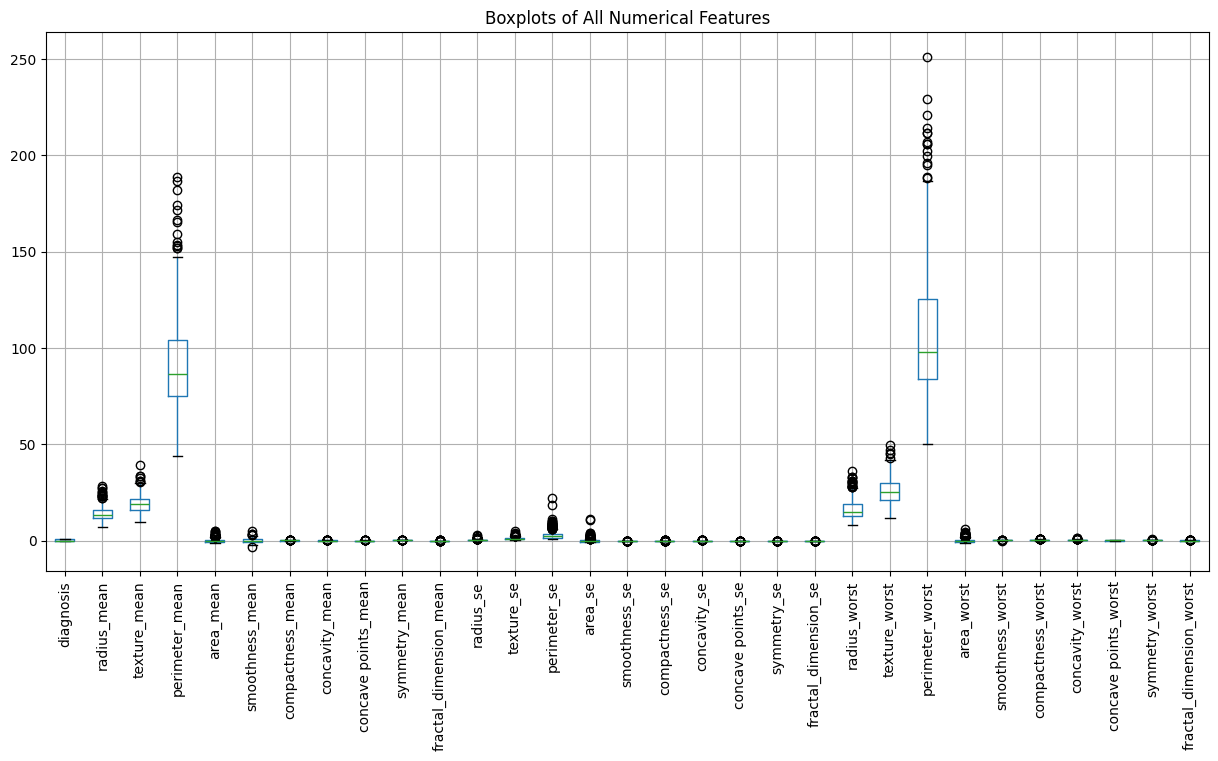

In [37]:
plt.figure(figsize=(15, 7))
data.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()

# Normalization

In [38]:
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
439,0.333144,0.201217,0.316495,0.196394,0.244019,0.111742,0.048899,0.131809,0.267172,0.124263,...,0.248310,0.194296,0.229693,0.123796,0.212838,0.072193,0.050000,0.282337,0.112557,0.079103
49,0.308060,0.425769,0.297975,0.177094,0.314977,0.176676,0.111317,0.168191,0.378283,0.152064,...,0.256848,0.527719,0.241994,0.126229,0.297365,0.139525,0.182268,0.440550,0.257441,0.092680
121,0.552747,0.250592,0.536314,0.395970,0.476393,0.277958,0.341378,0.430666,0.457576,0.256318,...,0.509427,0.343284,0.473081,0.335185,0.522552,0.195797,0.261342,0.575258,0.261975,0.193625
44,0.292915,0.409199,0.287679,0.164581,0.401824,0.261702,0.193510,0.261034,0.346465,0.248736,...,0.295269,0.476279,0.274366,0.136527,0.522552,0.352291,0.297764,0.552234,0.419476,0.269841
39,0.307587,0.375719,0.308272,0.176331,0.442087,0.325502,0.249063,0.270328,0.333333,0.299705,...,0.270366,0.373134,0.283331,0.136453,0.593211,0.383435,0.401757,0.775945,0.244826,0.341467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0.463770,0.307406,0.452699,0.315080,0.325178,0.222195,0.197329,0.326839,0.420707,0.113311,...,0.431163,0.380597,0.399871,0.264157,0.301327,0.179110,0.185144,0.506529,0.245417,0.113079
355,0.264045,0.316537,0.263493,0.145196,0.315699,0.258941,0.241331,0.218241,0.238889,0.250211,...,0.193525,0.277452,0.192290,0.089019,0.253781,0.167758,0.190735,0.318385,0.109600,0.110455
455,0.302854,0.710517,0.294036,0.175483,0.359484,0.168333,0.066050,0.162227,0.159091,0.214827,...,0.253291,0.788646,0.230490,0.127900,0.303969,0.111389,0.055935,0.266770,0.124384,0.142398
502,0.263098,0.223537,0.258863,0.141166,0.570281,0.273357,0.138894,0.162972,0.445960,0.340354,...,0.200640,0.250000,0.180587,0.090149,0.573400,0.143406,0.150879,0.289038,0.313424,0.133412


# Box Plot after Normalization

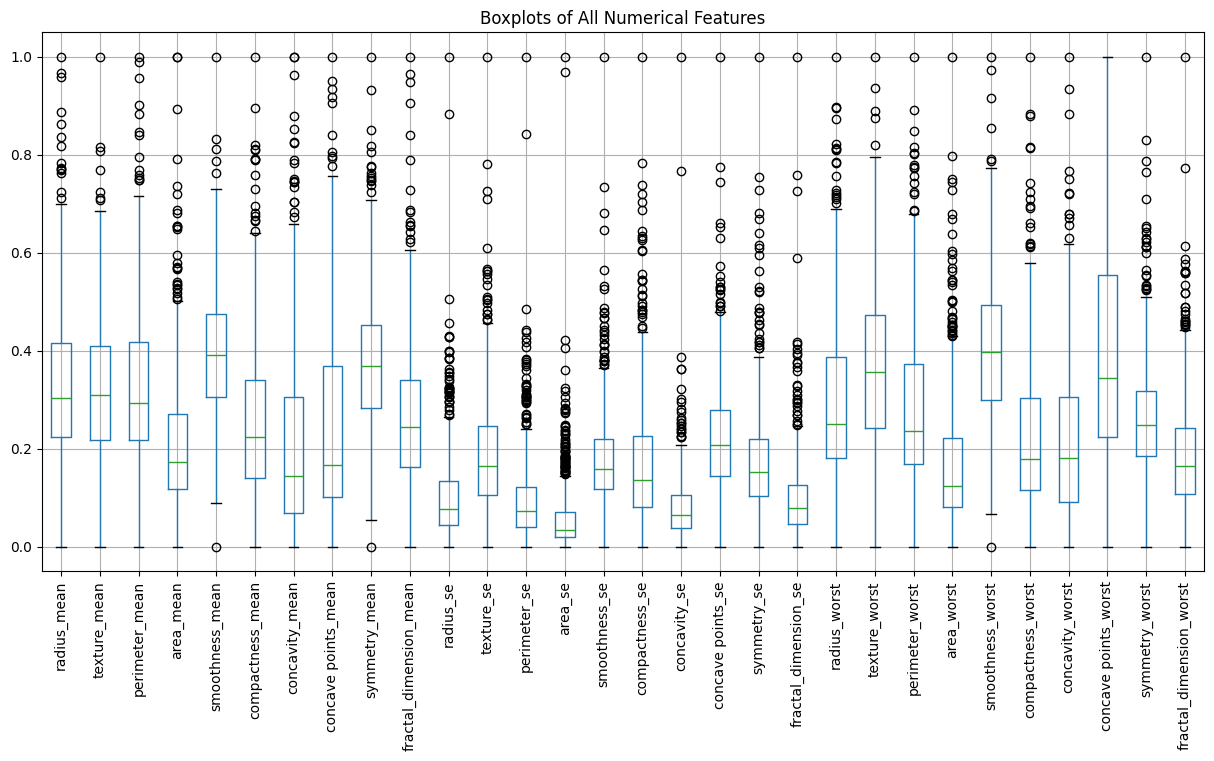

In [39]:
plt.figure(figsize=(15, 7))

x.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()

# Logistic Regression

Splitting data for training and testing.

In [40]:
from sklearn.model_selection import train_test_split

x_train, x_remaining, y_train, y_remaining = train_test_split(
    x, y, test_size=0.70, random_state=42
)

# Step 2: Split the remaining 60% into test1 (30%) and test2 (30%)
# Since remaining is 60%, splitting 50-50 gives 30%-30% of total
x_test1, x_test2, y_test1, y_test2 = train_test_split(
    x_remaining, y_remaining, test_size=0.5, random_state=42
)



print("x_train:", x_train.shape)
print("x_test1:", x_test1.shape)
print("x_test2:", x_test2.shape)
print("y_train:", y_train.shape)
print("y_test1:", y_test1.shape)
print("y_test2:", y_test2.shape)


x_train: (170, 30)
x_test1: (199, 30)
x_test2: (200, 30)
y_train: (170,)
y_test1: (199,)
y_test2: (200,)


Initializing Weight and bias

In [41]:
def initialize_weights_and_bias(dimension):
    w = np.random.randn(dimension, 1) * 0.01
    b = 0.0
    return w, b

Sigmoid Function to calculate z value.

In [42]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Forward-Backward Propagation

In [43]:
def forward_backward_propagation(w, b, x_train, y_train):
    m = x_train.shape[1]
    z = np.dot(w.T, x_train) + b
    y_head = sigmoid(z)

    lambda_ = 1.0

    cost = -(1/m) * np.sum(
        y_train * np.log(y_head) + (1 - y_train) * np.log(1 - y_head)
    ) + (lambda_ / (2 * m)) * np.sum(np.square(w))




    derivative_weight = (1/m) * np.dot(x_train, (y_head - y_train).T) + (lambda_ / m) * w
    derivative_bias = (1/m) * np.sum(y_head - y_train)

    gradients = {"derivative_weight": derivative_weight, "derivative_bias": derivative_bias}
    return cost, gradients

Updating Parameters

In [44]:
def update(w, b, x_train, y_train, learning_rate, num_iterations):
    costs = []
    gradients = {}
    for i in range(num_iterations):
        cost, grad = forward_backward_propagation(w, b, x_train, y_train)
        w -= learning_rate * grad["derivative_weight"]
        b -= learning_rate * grad["derivative_bias"]

        if i % 100 == 0:
            costs.append(cost)
            print(f"Cost after iteration {i}: {cost}")

    parameters = {"weight": w, "bias": b}
    return parameters, gradients, costs

 Making Predictions

In [45]:
def predict(w, b, x_test):
    m = x_test.shape[1]
    y_prediction = np.zeros((1, m))
    z = sigmoid(np.dot(w.T, x_test) + b)

    for i in range(z.shape[1]):
        y_prediction[0, i] = 1 if z[0, i] > 0.45 else 0

    return y_prediction

In [46]:
import numpy as np

# Adjust x_train and y_train to fit the expected shape (n_features, n_samples)
# for x and (1, n_samples) for y, as required by the custom logistic regression functions.
x_train_processed = x_train.T  # Transpose x_train from (n_samples, n_features) to (n_features, n_samples)
y_train_processed = y_train.reshape(1, -1)  # Reshape y_train from (n_samples,) to (1, n_samples)

# The dimension for weights should be the number of features
dimension = x_train_processed.shape[0]  # This will be the number of features (30)
w, b = initialize_weights_and_bias(dimension)

parameters, gradients, costs = update(w, b, x_train_processed, y_train_processed, learning_rate=0.01, num_iterations=1000)

y_prediction_train = predict(parameters["weight"], parameters["bias"], x_train_processed)

# Calculate training accuracy
# y_prediction_train is (1, N_samples), y_train_processed is (1, N_samples), so direct comparison works.
train_accuracy = 100 - np.mean(np.abs(y_prediction_train - y_train_processed)) * 100
print(f"Training accuracy: {train_accuracy:.2f}%")


Cost after iteration 0: 0.6927801553124066
Cost after iteration 100: 0.6660456085207505
Cost after iteration 200: 0.6424596716361058
Cost after iteration 300: 0.6209701659288701
Cost after iteration 400: 0.6012422386528822
Cost after iteration 500: 0.5830845498250239
Cost after iteration 600: 0.5663435906246623
Cost after iteration 700: 0.5508839146120668
Cost after iteration 800: 0.5365839114705241
Cost after iteration 900: 0.523334286587708
Training accuracy: 87.65%


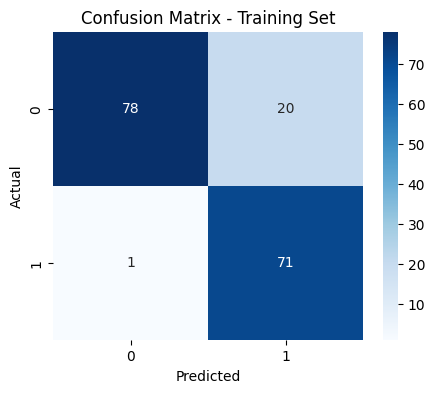

In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_train = confusion_matrix(y_train, y_prediction_train.T)

plt.figure(figsize=(5,4))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Training Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_train, y_prediction_train.T)

TP = cm_train[1, 1]
FP = cm_train[0, 1]
TN = cm_train[0, 0]
FN = cm_train[1, 0]

precision_train = TP / (TP + FP)
recall_train = TP / (TP + FN)
specificity_train = TN / (TN + FP)
accuracy_train = (TP + TN) / (TP + TN + FP + FN)
F1_train = 2 * (precision_train * recall_train) / (precision_train + recall_train)

print("Metrics for Training Set (SVM):")
print(f"Accuracy: {accuracy_train:.2f}")
print(f"Precision: {precision_train:.2f}")
print(f"Recall: {recall_train:.2f}")
print(f"Specificity: {specificity_train:.2f}")
print(f"F1 score: {F1_train:.2f}")

Metrics for Training Set (SVM):
Accuracy: 0.88
Precision: 0.78
Recall: 0.99
Specificity: 0.80
F1 score: 0.87


# Test 1

In [50]:
# Predict on test1 set
y_prediction_test1 = predict(parameters["weight"], parameters["bias"], x_test1.T)

# Calculate test1 accuracy
test1_accuracy = 100 - np.mean(np.abs(y_prediction_test1 - y_test1.reshape(1, -1))) * 100
print(f"Test1 accuracy: {test1_accuracy:.2f}%")


Test1 accuracy: 89.45%


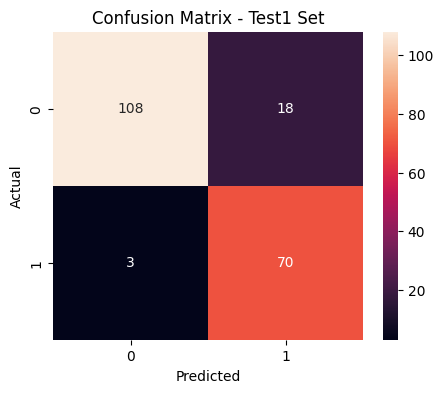

In [51]:
cm_test1 = confusion_matrix(y_test1, y_prediction_test1.T)

plt.figure(figsize=(5,4))
sns.heatmap(cm_test1, annot=True, fmt="d")
plt.title("Confusion Matrix - Test1 Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for test1
cm_test1 = confusion_matrix(y_test1.T, y_prediction_test1.T)

TP = cm_test1[1, 1]
FP = cm_test1[0, 1]
TN = cm_test1[0, 0]
FN = cm_test1[1, 0]

precision_test1 = TP / (TP + FP)
recall_test1 = TP / (TP + FN)
specificity_test1 = TN / (TN + FP)
accuracy_test1 = (TP + TN) / (TP + TN + FP + FN)
F1_test1 = 2 * (precision_test1 * recall_test1) / (precision_test1 + recall_test1)

print("Metrics for Test1 Set:")
print(f"Accuracy: {accuracy_test1:.2f}")
print(f"Precision: {precision_test1:.2f}")
print(f"Recall (Sensitivity): {recall_test1:.2f}")
print(f"Specificity: {specificity_test1:.2f}")
print(f"F1 score: {F1_test1:.2f}")


Metrics for Test1 Set:
Accuracy: 0.89
Precision: 0.80
Recall (Sensitivity): 0.96
Specificity: 0.86
F1 score: 0.87


# Test 2

In [54]:

y_prediction_test2 = predict(parameters["weight"], parameters["bias"], x_test2.T)

test2_accuracy = 100 - np.mean(np.abs(y_prediction_test2 - y_test2.reshape(1, -1))) * 100
print(f"Test2 accuracy: {test2_accuracy:.2f}%")


Test2 accuracy: 88.50%


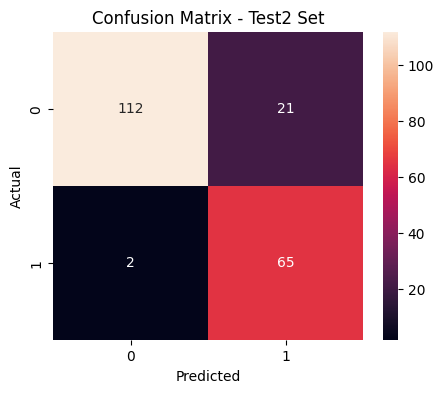

In [55]:
cm_test2 = confusion_matrix(y_test2, y_prediction_test2.T)

plt.figure(figsize=(5,4))
sns.heatmap(cm_test2, annot=True, fmt="d")
plt.title("Confusion Matrix - Test2 Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:

cm_test2 = confusion_matrix(y_test2.T, y_prediction_test2.T)

TP = cm_test2[1, 1]
FP = cm_test2[0, 1]
TN = cm_test2[0, 0]
FN = cm_test2[1, 0]

precision_test2 = TP / (TP + FP)
recall_test2 = TP / (TP + FN)
specificity_test2 = TN / (TN + FP)
accuracy_test2 = (TP + TN) / (TP + TN + FP + FN)
F1_test2 = 2 * (precision_test2 * recall_test2) / (precision_test2 + recall_test2)

print("Metrics for Test2 Set:")
print(f"Accuracy: {accuracy_test2:.2f}")
print(f"Precision: {precision_test2:.2f}")
print(f"Recall (Sensitivity): {recall_test2:.2f}")
print(f"Specificity: {specificity_test2:.2f}")
print(f"F1 score: {F1_test2:.2f}")


Metrics for Test2 Set:
Accuracy: 0.89
Precision: 0.76
Recall (Sensitivity): 0.97
Specificity: 0.84
F1 score: 0.85
